In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob 
import os

In [10]:
import re
df_list = []
file_paths = sorted(glob.glob("data/california/CRMLSSold*.csv"))
for file in file_paths:
    # Extract the 6-digit date string (e.g., '202401') from the filename using regex
    filename = os.path.basename(file)
    match = re.search(r"CRMLSSold(\d{4})(\d{2})", filename)

    if match:
        year = int(match.group(1))
        month = int(match.group(2))
    else:
        # Fallback if filename structure varies slightly
        year = None
        month = None

    # Read the individual CSV
    temp_df = pd.read_csv(file)

    # Inject the engineered time features into this specific batch of data
    temp_df["Year"] = year
    temp_df["Month"] = month
    # Useful as a string format (e.g., "2024-01") for plotting chronological trends later
    temp_df["YearMonth"] = f"{year}-{month:02d}" if year else None

    df_list.append(temp_df)

# 2. Concatenate everything together
df = pd.concat(df_list, axis=0, ignore_index=True)


C:\Users\CiciA\AppData\Local\Temp\ipykernel_72408\902620439.py:18: DtypeWarning: Columns (78,79) have mixed types. Specify dtype option on import or set low_memory=False.
  temp_df = pd.read_csv(file)
C:\Users\CiciA\AppData\Local\Temp\ipykernel_72408\902620439.py:18: DtypeWarning: Columns (2,36,39,56,74) have mixed types. Specify dtype option on import or set low_memory=False.
  temp_df = pd.read_csv(file)
C:\Users\CiciA\AppData\Local\Temp\ipykernel_72408\902620439.py:18: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  temp_df = pd.read_csv(file)
C:\Users\CiciA\AppData\Local\Temp\ipykernel_72408\902620439.py:18: DtypeWarning: Columns (4,74) have mixed types. Specify dtype option on import or set low_memory=False.
  temp_df = pd.read_csv(file)


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 794271 entries, 0 to 794270
Data columns (total 85 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   Flooring                      465886 non-null  object 
 1   ViewYN                        707277 non-null  object 
 2   WaterfrontYN                  434 non-null     object 
 3   BasementYN                    13172 non-null   object 
 4   PoolPrivateYN                 690017 non-null  object 
 5   OriginalListPrice             791935 non-null  float64
 6   ListingKey                    794271 non-null  int64  
 7   ListAgentEmail                792478 non-null  object 
 8   CloseDate                     794271 non-null  object 
 9   ClosePrice                    794263 non-null  float64
 10  ListAgentFirstName            789394 non-null  object 
 11  ListAgentLastName             794180 non-null  object 
 12  Latitude                      793455 non-nul

In [18]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Flooring,465886,366,Wood,52442,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ViewYN,707277,2,True,430811,NaN,NaN,NaN,NaN,NaN,NaN,NaN
WaterfrontYN,434,1,True,434,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BasementYN,13172,1,True,13172,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PoolPrivateYN,690017,2,False,609970,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
Year,794271.0,NaN,NaN,NaN,2024.191597,1.268336,2022.0,2024.0,2024.0,2025.0,2026.0
Month,794271.0,NaN,NaN,NaN,4.997965,3.579951,1.0,1.0,4.0,8.0,12.0
YearMonth,794271,30,2022-01,157828,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BuyerAgentAOR,544413,63,OrangeCounty,53197,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
df.columns

Index(['Flooring', 'ViewYN', 'WaterfrontYN', 'BasementYN', 'PoolPrivateYN',
       'OriginalListPrice', 'ListingKey', 'ListAgentEmail', 'CloseDate',
       'ClosePrice', 'ListAgentFirstName', 'ListAgentLastName', 'Latitude',
       'Longitude', 'UnparsedAddress', 'PropertyType', 'LivingArea',
       'ListPrice', 'DaysOnMarket', 'ListOfficeName', 'BuyerOfficeName',
       'CoListOfficeName', 'ListAgentFullName', 'CoListAgentFirstName',
       'CoListAgentLastName', 'BuyerAgentMlsId', 'BuyerAgentFirstName',
       'BuyerAgentLastName', 'FireplacesTotal', 'AssociationFeeFrequency',
       'AboveGradeFinishedArea', 'ListingKeyNumeric', 'MLSAreaMajor',
       'TaxAnnualAmount', 'CountyOrParish', 'MlsStatus', 'ElementarySchool',
       'AttachedGarageYN', 'ParkingTotal', 'BuilderName', 'PropertySubType',
       'LotSizeAcres', 'SubdivisionName', 'BuyerOfficeAOR', 'YearBuilt',
       'BuyerAgencyCompensationType', 'StreetNumberNumeric', 'ListingId',
       'BathroomsTotalInteger', 'City', 'Bu

In [23]:
df.isnull().sum().sort_values(ascending=False)

MiddleOrJuniorSchoolDistrict    794271
ElementarySchoolDistrict        794271
CoveredSpaces                   794271
AboveGradeFinishedArea          794271
FireplacesTotal                 794271
                                 ...  
ListingKey                           0
PropertyType                         0
Year                                 0
YearMonth                            0
Month                                0
Length: 85, dtype: int64

In [25]:
summary = pd.DataFrame({
    "dtype": df.dtypes,
    "missing": df.isnull().sum(),
    "missing_pct": df.isnull().mean()*100,
    "unique": df.nunique()
})
\
summary = summary[summary["missing"] > 0]
summary.sort_values(
    "missing_pct",
    ascending=False
)

,dtype,missing,missing_pct,unique
CoveredSpaces,float64,794271,100.000000,0
FireplacesTotal,float64,794271,100.000000,0
MiddleOrJuniorSchoolDistrict,float64,794271,100.000000,0
ElementarySchoolDistrict,float64,794271,100.000000,0
AboveGradeFinishedArea,float64,794271,100.000000,0
...,...,...,...,...
MlsStatus,object,1,0.000126,1
ListOfficeName,object,1,0.000126,24449
DaysOnMarket,float64,1,0.000126,1443
CountyOrParish,object,1,0.000126,64


<Axes: >

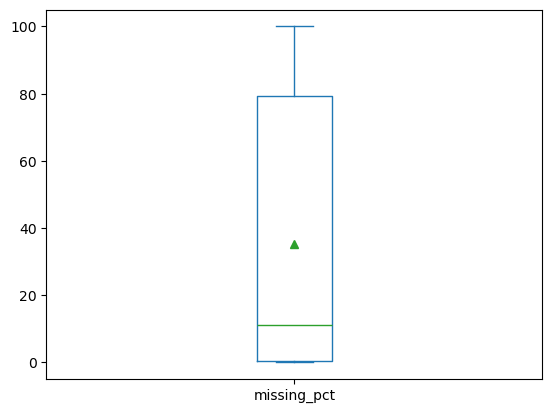

In [33]:
summary['missing_pct'].plot(kind = 'box',showmeans=True)

<Axes: >

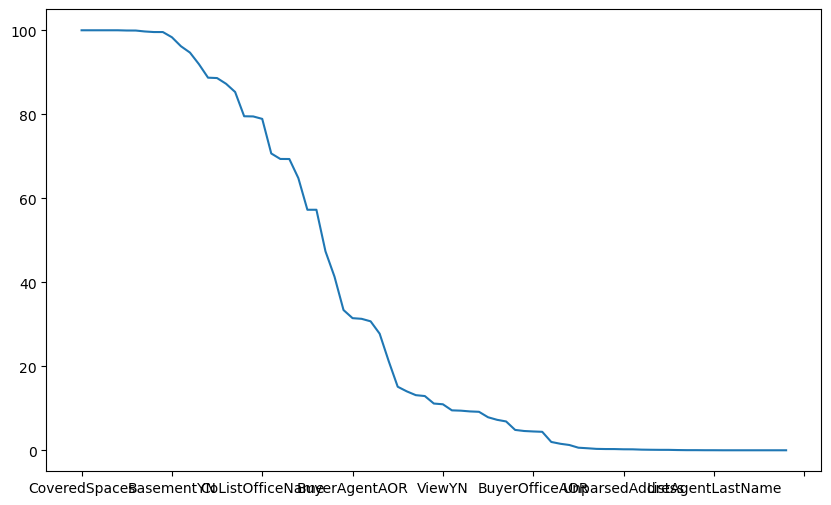

In [35]:
summary['missing_pct'].sort_values(ascending=False).plot(kind='line', figsize=(10,6))